# Nowcasting Autoencoder Tutorial

Creating an effective autoencoder is a great first step in developing a predictive model. Learning how to create a high-quality latent state is critical, and can later be used to train a new encoder for a pre-existing predictive model, or a new decoder. An example for this could be training an encoder which uses different or fewer variables than the original model. Another might be training a higher-resolution decoder which is capable of producing higher-resolution predictions from the same latent state.

Autoencoders are also a great concept to learn when understanding neural network architectures.

In this example, we first blend radar and satellite data onto the same grid, then train an autoencoder to perform dimensionality reduction and produce a useful latent state which can be used to resonstruct the original inputs.

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import datetime

In [2]:
import pyearthtools.data as petdata
import pyearthtools.pipeline as petpipe


If you are not at the NCI site, then change the following cell to import the correct site_archive

In [3]:
import site_archive_nci

In [4]:
from pyearthtools.data.time import Petdt
from pyearthtools.pipeline.operations.xarray.join import GeospatialTimeSeriesMerge


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim

In [6]:
# Set random seed for reproducibility
torch.manual_seed(42)

# Autodetect GPU and use if possible
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

## Load and prepare data

In [7]:
rf3proj = petdata.transforms.projection.Rainfields3ProjAus()
radar_projector = petdata.transforms.projection.XYtoLonLatRectilinear(rf3proj)

In [8]:
# We specify the date, hour, and minute for querying data
selected_date = datetime.datetime(2021,6,9,2,0)

In [9]:
himawari = petdata.archive.Himawari('surface_global_irradiance')

In [10]:
himawari[selected_date]

/home/005/sh7673/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:790: IndexWarning: Data requested at a higher resolution than available. nanosecond > minute
  warnings.warn(


<xarray.Dataset> Size: 31MB
Dimensions:                    (time: 1, latitude: 1726, longitude: 2214)
Coordinates:
  * time                       (time) datetime64[ns] 8B 2021-06-09T02:00:00
  * latitude                   (latitude) float32 7kB -44.5 -44.48 ... -10.0
  * longitude                  (longitude) float32 9kB 112.0 112.0 ... 156.3
Data variables:
    surface_global_irradiance  (time, latitude, longitude) float64 31MB dask.array<chunksize=(1, 1726, 2214), meta=np.ndarray>
Attributes: (12/58)
    Conventions:                      CF-1.7
    Metadata_Conventions:             Unidata Dataset Discovery v1.0
    acknowledgment:                   The following acknowledgement is requir...
    cdm_data_type:                    grid
    comment:                          Solar radiation data derived from satel...
    contributor_name:                 Mines ParisTech; Commonwealth of Austra...
    ...                               ...
    quality:                          0
    quality_meaning:                  0: no_known_issues 1: known_issue 
    project:                          Gridded Solar Observations
    history:                          Mon Mar  4 01:55:08 2024: ncatted -a re...
    references:                       Poulsen C., Majewski L. J. (2022) Gridd...
    NCO:                              netCDF Operators version 4.7.7 (Homepag...

In [11]:
# TODO: It would be nice if this normalised the data nicely
satpipe = petpipe.Pipeline(
    himawari
)

In [12]:
himawari_sample = satpipe['20210609T0200']
himawari_sample

<xarray.Dataset> Size: 31MB
Dimensions:                    (time: 1, latitude: 1726, longitude: 2214)
Coordinates:
  * time                       (time) datetime64[ns] 8B 2021-06-09T02:00:00
  * latitude                   (latitude) float32 7kB -44.5 -44.48 ... -10.0
  * longitude                  (longitude) float32 9kB 112.0 112.0 ... 156.3
Data variables:
    surface_global_irradiance  (time, latitude, longitude) float64 31MB dask.array<chunksize=(1, 1726, 2214), meta=np.ndarray>
Attributes: (12/58)
    Conventions:                      CF-1.7
    Metadata_Conventions:             Unidata Dataset Discovery v1.0
    acknowledgment:                   The following acknowledgement is requir...
    cdm_data_type:                    grid
    comment:                          Solar radiation data derived from satel...
    contributor_name:                 Mines ParisTech; Commonwealth of Austra...
    ...                               ...
    quality:                          0
    quality_meaning:                  0: no_known_issues 1: known_issue 
    project:                          Gridded Solar Observations
    history:                          Mon Mar  4 01:55:08 2024: ncatted -a re...
    references:                       Poulsen C., Majewski L. J. (2022) Gridd...
    NCO:                              netCDF Operators version 4.7.7 (Homepag...

In [13]:
fullsat = petpipe.Pipeline(
    satpipe,
    # GeospatialTimeSeriesMerge(reference_dataset=himawari_sample), # These are pretty similar grids, so just pick one
    # petdata.transforms.variables.Drop(['x_bounds', 'y_bounds', 'proj', 'x', 'y']),
    petpipe.operations.xarray.Sort(order=['time', 'latitude', 'longitude']),  # 
    # Align the data variable's coordinate order to the dataset coordinate order so all arrays are the same shape
    petpipe.operations.xarray.AlignDataVariableDimensionsToDatasetCoords(),  
    petdata.transform.region.Bounding(-35, -25, 138, 150),  # cut down on region for example
    petpipe.operations.xarray.normalisation.SingleValueDivision(1200),
    petpipe.operations.xarray.conversion.ToNumpy(),
    petpipe.operations.numpy.reshape.Rearrange('c t h w -> t c h w'), # channel time height width -> time channel height width
    iterator=petpipe.iterators.DateRange('20200101T00', '20210101T00', interval='10 minutes'),
    exceptions_to_ignore=petdata.exceptions.DataNotFoundError
)


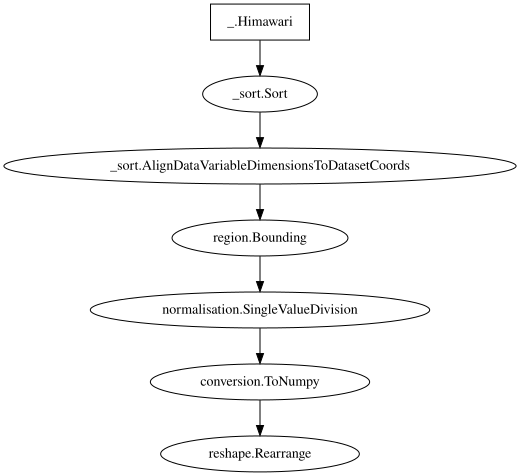

In [14]:
fullsat

In [15]:
ipipe = iter(fullsat)  # Make an iterator to walk the time period
ipipe

<generator object Pipeline.__iter__ at 0x14aef6d7b6e0>

In [16]:
fullsat.exceptions_to_ignore

(pyearthtools.data.exceptions.DataNotFoundError,)

In [17]:
n = next(ipipe)
n

array([[[[0.73251667, 0.73271667, 0.73290833, ..., 0.53389167,
          0.52780833, 0.513675  ],
         [0.732625  , 0.732825  , 0.73301667, ..., 0.51565833,
          0.51565833, 0.5015    ],
         [0.73284167, 0.73303333, 0.73323333, ..., 0.51574167,
          0.49040833, 0.49040833],
         ...,
         [0.71599167, 0.71619167, 0.71638333, ..., 0.810125  ,
          0.704325  , 0.80504167],
         [0.715875  , 0.71596667, 0.71619167, ..., 0.80789167,
          0.701475  , 0.80384167],
         [0.715875  , 0.71596667, 0.71619167, ..., 0.80460833,
          0.80255   , 0.80276667]]]], shape=(1, 1, 501, 601))

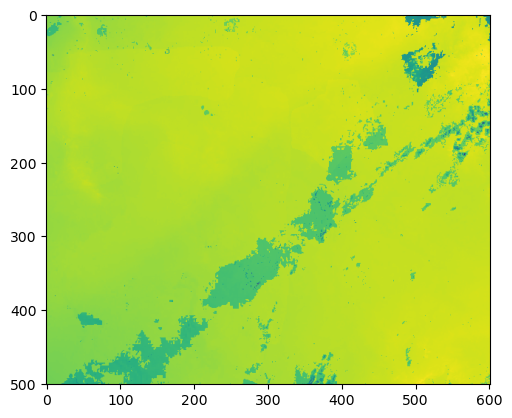

In [18]:
plt.imshow(n[0][0])

### Define the Autoencoder architecture
Here we define an "AutoEncoder". This is a model which reproduces its inputs, through a bottleneck layer. It is one of the primary concepts behind many  neural network architectures that you will work with in future, and is key to  conceptual understanding as well as being sometimes useful in understanding the dataset.

In [19]:
# Reminder, the image size is latitude: 1726, longitude: 2214

class AutoEncoder(nn.Module):
    def __init__(self, 
                 input_height = 501,
                 input_width = 601,
                 kernel_size = 4,
                 stride=2,
                 input_channel_count = 2,
                 output_channel_count = 2,
                 latent_dim=300):
        super(AutoEncoder, self).__init__()

        self.input_width = input_width
        self.input_height = input_height
        self.input_channel_count = input_channel_count
        self.output_channel_count = output_channel_count

        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels=self.input_channel_count, out_channels=16, kernel_size=kernel_size, stride = stride, padding = 1),
            nn.ReLU(),
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride =2, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=7),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=7),
            nn.ReLU(),
            nn.ConvTranspose2d(in_channels=32, out_channels=16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(in_channels=16, out_channels=self.output_channel_count, kernel_size=kernel_size, stride=stride, padding=1, output_padding=1),
            nn.Sigmoid()
        )
        

    def forward(self, x):

        # Get latent representation
        latent = self.encoder(x)

        # Reconstruct input
        reconstructed = self.decoder(latent)

        return reconstructed

In [20]:
# Initialize model and move to device
model = AutoEncoder(input_channel_count=1, output_channel_count=1).to(device)

# Loss function and optimizer
criterion = nn.L1Loss()
# criterion = nn.KLDivLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [21]:
n

array([[[[0.73251667, 0.73271667, 0.73290833, ..., 0.53389167,
          0.52780833, 0.513675  ],
         [0.732625  , 0.732825  , 0.73301667, ..., 0.51565833,
          0.51565833, 0.5015    ],
         [0.73284167, 0.73303333, 0.73323333, ..., 0.51574167,
          0.49040833, 0.49040833],
         ...,
         [0.71599167, 0.71619167, 0.71638333, ..., 0.810125  ,
          0.704325  , 0.80504167],
         [0.715875  , 0.71596667, 0.71619167, ..., 0.80789167,
          0.701475  , 0.80384167],
         [0.715875  , 0.71596667, 0.71619167, ..., 0.80460833,
          0.80255   , 0.80276667]]]], shape=(1, 1, 501, 601))

### Prediction from untrained Autoencoder
Here we demonstrate how if we make a prediction before training randomly initialised weights, we get garbage out. 
]Tis also demonstrates how we move the data into the GPU memory in oder to do inference on the GPU, and then move it back to the CPU to analyse it further.

In [22]:
x = torch.from_numpy(n).float().to(device)

In [23]:
# This should make us a messy prediction from an untrained model in the dimension of the input
prediction = model.forward(x)

In [24]:
image_numpy_for_display = prediction.to('cpu').detach().numpy()
image_numpy_for_display

array([[[[0.50065696, 0.48921508, 0.50447506, ..., 0.5048941 ,
          0.49451593, 0.49649683],
         [0.49091142, 0.48471972, 0.49740216, ..., 0.49655902,
          0.4854901 , 0.49569237],
         [0.50525343, 0.49127102, 0.50628036, ..., 0.5060294 ,
          0.49593538, 0.49206153],
         ...,
         [0.5056908 , 0.49159676, 0.50627095, ..., 0.5070522 ,
          0.4962155 , 0.49216732],
         [0.49466008, 0.48274752, 0.49926758, ..., 0.49908406,
          0.4909126 , 0.49494073],
         [0.496664  , 0.4933806 , 0.4925769 , ..., 0.49220595,
          0.4916225 , 0.48608866]]]],
      shape=(1, 1, 501, 601), dtype=float32)

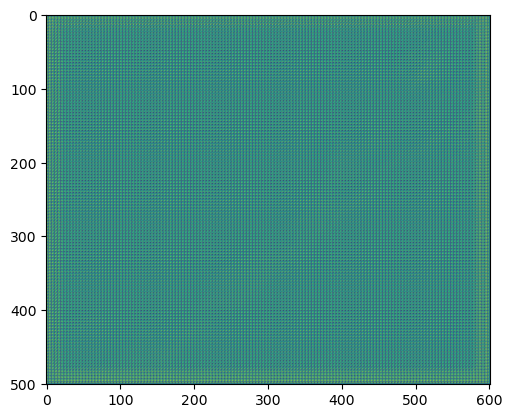

In [25]:
plt.imshow(image_numpy_for_display[0][0])

Now we define the training loop function and run the training. # 1000 samples is taking about 2 minutes It should be able to go much much much faster, but still we can test it and make progress. Let's to 30 minutes of training, i.e. 15k samples

In [26]:
def train(debug=True, num_epochs=1, max_samples=10, print_per=20):
    """
    Main Training loop Function
    """
    sample_ix = 0 
    
    
    for epoch in range(num_epochs):
        total_loss = 0    
        epoch_samples = 0
        ipipe = iter(fullsat)  # Make an iterator to walk the time period
    
        while True:
            try:
                sample = next(ipipe)
            except StopIteration:
                break  # advance the epoch loop
            except:
                pass # some samples are just missing
    
            sample_ix += 1
            epoch_samples += 1
            if epoch_samples % print_per == 0:
                print(epoch_samples)
            
            if sample_ix > max_samples:
                break

            if debug:
                print(sample_ix)
    
            x = torch.from_numpy(sample).float().to(device)   

            if torch.any(torch.isnan(x)):
                # Skip nan inputs, they break the training
                continue
                
            if debug:
                print("Input")
                print(x)
    
            optimizer.zero_grad()
    
            # Forward pass
            y = model.forward(x)

            if debug:
                print("prediction")
                print(y)
            
            loss = criterion(y, x)
            if debug:
                print("loss")
                print(loss)
    
            # Backward pass and optimize        
            loss.backward()
            optimizer.step()
    
            total_loss += loss.item()
    
        # Print epoch statistics
        avg_loss = total_loss / epoch_samples
        epoch_samples = 0  # Reset for next epoch
        print(f'Epoch [{epoch+1}/{epoch_samples}], Average Loss: {avg_loss:.4f}')

In [27]:
%%time
train(debug=False, num_epochs=1, max_samples=15 * 1000, print_per = 500)

500
1000
1500
2000
2500
3000
3500
4000
4500
5000
5500
6000
6500
7000
7500
8000
8500
9000
9500
10000
10500
11000
11500
12000
12500
13000
13500
14000
14500
15000
Epoch [1/0], Average Loss: 0.0382
CPU times: user 30min 7s, sys: 4min 56s, total: 35min 4s
Wall time: 41min 10s


### Make predictions

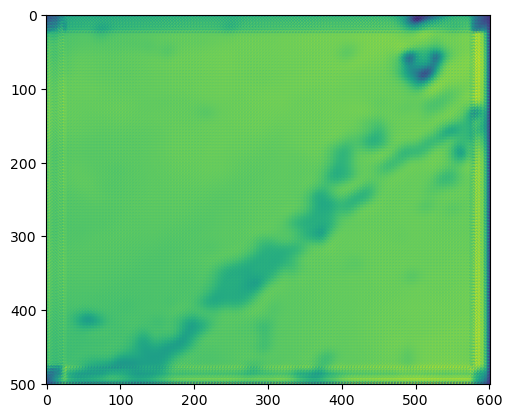

In [28]:
prediction = model.forward(x)
image_numpy_for_display = prediction.to('cpu').detach().numpy()
plt.imshow(image_numpy_for_display[0][0])

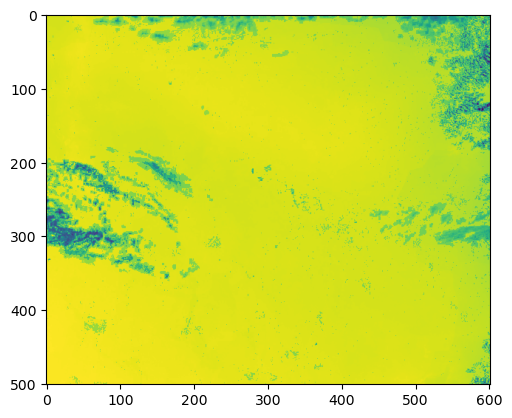

In [29]:


z = torch.from_numpy(fullsat['20210303T0400']).float().to(device)

image_numpy_for_display = z.to('cpu').detach().numpy()
plt.imshow(image_numpy_for_display[0][0])

In [30]:
latent = model.encoder(z)

In [31]:
latent.shape

torch.Size([1, 64, 119, 144])

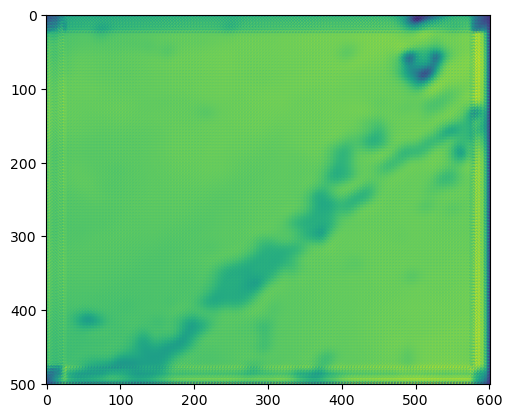

In [32]:
reconstruction = model.forward(z)
image_numpy_for_display = prediction.to('cpu').detach().numpy()
plt.imshow(image_numpy_for_display[0][0])

### Further reading

* [PyTorch Lightning Autoencoder](https://lightning.ai/docs/pytorch/stable/notebooks/course_UvA-DL/08-deep-autoencoders.html)
* 
